In [ ]:
!pip install -q gdown

In [ ]:
import gdown
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Preparación de la fuente de datos y librerías

In [ ]:
file_id = "1HDKmAgX3ESEshPGIjx28ii65OhaPgiMG"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1HDKmAgX3ESEshPGIjx28ii65OhaPgiMG
From (redirected): https://drive.google.com/uc?id=1HDKmAgX3ESEshPGIjx28ii65OhaPgiMG&confirm=t&uuid=1e7f8d4b-7f11-490c-9454-6ce5a2e32475
To: /content/data.csv
100%|██████████| 523M/523M [00:07<00:00, 65.5MB/s]


'data.csv'

In [ ]:
df = pd.read_csv("data.csv", low_memory=False)

#df.head()

## Introducción



## <span style="color:Blue;"><strong>1. Introducción</strong></span>

<div style="background-color:#E6F4FF; padding:102px; border-radius:8px;">
<b>1. Breve presentación del problema o pregunta de investigación.</b>  
</div>

¿Cómo influyen el sexo y el grupo étnico del solicitante en la asignación de la Tasa Efectiva Promedio Ponderada, y de qué manera esta relación se ve afectada por el rango del monto desembolsado y la condición de ser un deudor nuevo en la entidad?

<br>
<div style="background-color:#E8F5E9; padding:12x; border-radius:8px;">
<b> 2. Contexto:¿por qué es relevante este problema? </b>
</div>

El acceso equitativo al sistema financiero es un pilar del desarrollo social. En el mercado de las tarjetas de crédito, las tasas de interés no solo dependen de políticas macroeconómicas, sino también de la evaluación de riesgo que las entidades hacen de cada individuo. **Es fundamental investigar si existen brechas de costos asociadas a características demográficas como el sexo o la pertenencia a grupos étnicos, ya que esto podría revelar barreras invisibles en la inclusión financiera.**

Además, la distinción entre un deudor nuevo y uno antiguo, sumada al rango del monto desembolsado, permite analizar si el sistema financiero premia la fidelidad o si, por el contrario, utiliza tasas de entrada competitivas para captar nuevos usuarios, y si este comportamiento es uniforme para todos los niveles de ingresos y perfiles demográficos.

<div style="background-color:#FFF9C4; padding:12px; border-radius:8px;">
<b> 3. Relación entre el problema y la base de datos seleccionada. </b>  
</div>

Para abordar esta pregunta, utilizamos el conjunto de datos del repositorio Datos Abiertos de Colombia sobre tarifas de tarjetas de crédito. Esta base de datos es particularmente valiosa porque desglosa la información en variables cualitativas, tales como: Sexo (Femenino, Masculino, Trans), Grupo_Etnico y Clase_deudor. Al cruzar estas categorías con la variable cuantitativa Tasa_efectiva_promedio_ponderada y la variable ordinal Rango_monto_desembolsado, el dataset permite realizar un análisis sobre la equidad en el costo del dinero y el comportamiento de las entidades frente a diferentes perfiles de riesgo y vulnerabilidad.

##**2. Descripción de la base de datos**




In [ ]:
df.head()

,Tipo_Entidad,Nombre_Tipo_Entidad,Codigo_Entidad,Nombre_Entidad,Fecha_Corte,Tipo_de_persona,Sexo,Tamaño_de_empresa,Tipo_de_crédito,Tipo_de_garantía,...,margen_adicional,Montos_desembolsados,Numero_de_creditos_desembolsados,Grupo_Etnico,Antiguedad_de_la_empresa,Tipo_de_Tasa,Rango_monto_desembolsado,Clase_deudor,Codigo_CIIU,Codigo_Municipio
0,1,BC-ESTABLECIMIENTO BANCARIO,1,Banco de Bogotá,05/07/2024,Natural,Femenino,No aplica,Consumo,Sin garantia,...,0,198.350,1.0,Sin información (1),No aplica(1),FS,Hasta 1 SMLMV,Deudor nuevo en la entidad,4719,5284
1,1,BC-ESTABLECIMIENTO BANCARIO,1,Banco de Bogotá,05/07/2024,Natural,Femenino,No aplica,Consumo,Sin garantia,...,0,183.710,1.0,Sin información (1),No aplica(1),FS,Hasta 1 SMLMV,Deudor nuevo en la entidad,4719,5001
2,1,BC-ESTABLECIMIENTO BANCARIO,1,Banco de Bogotá,05/07/2024,Natural,Femenino,No aplica,Consumo,Sin garantia,...,0,241.000,1.0,Sin información (1),No aplica(1),FS,Hasta 1 SMLMV,Deudor nuevo en la entidad,4711,86568
3,1,BC-ESTABLECIMIENTO BANCARIO,1,Banco de Bogotá,05/07/2024,Natural,Femenino,No aplica,Consumo,Sin garantia,...,0,119.365,1.0,Sin información (1),No aplica(1),FS,Hasta 1 SMLMV,Deudor nuevo en la entidad,4711,85010
4,1,BC-ESTABLECIMIENTO BANCARIO,1,Banco de Bogotá,05/07/2024,Natural,Femenino,No aplica,Consumo,Sin garantia,...,0,1.275.973,10.0,Sin información (1),No aplica(1),FS,Hasta 1 SMLMV,Deudor nuevo en la entidad,10,47189


In [ ]:
def explorar_dataframe(df, nombre="DataFrame"):
    """
    Resumen exploratorio de un DataFrame:
    - Número de registros y forma
    - Lista de columnas
    - Tipos de datos y memoria
    - Conteo de valores nulos
    - Número de duplicados
    - Primeras filas como muestra
    """
    print(f"\n===== {nombre} =====")
    print("Número de registros:", len(df))
    print(f"Número de variables: {df.shape[1]}")
    print("Forma:", df.shape)
    print("Columnas:", df.columns.tolist())
    print("\n--- Info ---")
    print(df.info())


In [ ]:
explorar_dataframe(df)


===== DataFrame =====
Número de registros: 1539686
Número de variables: 23
Forma: (1539686, 23)
Columnas: ['Tipo_Entidad', 'Nombre_Tipo_Entidad', 'Codigo_Entidad', 'Nombre_Entidad', 'Fecha_Corte', 'Tipo_de_persona', 'Sexo', 'Tamaño_de_empresa', 'Tipo_de_crédito', 'Tipo_de_garantía', 'Producto de crédito', 'Plazo de crédito', 'Tasa_efectiva_promedio_ponderada', 'margen_adicional', 'Montos_desembolsados', 'Numero_de_creditos_desembolsados', 'Grupo_Etnico', 'Antiguedad_de_la_empresa', 'Tipo_de_Tasa', 'Rango_monto_desembolsado', 'Clase_deudor', 'Codigo_CIIU', 'Codigo_Municipio']

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1539686 entries, 0 to 1539685
Data columns (total 23 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   Tipo_Entidad                      1539686 non-null  int64  
 1   Nombre_Tipo_Entidad               1539686 non-null  object 
 2   Codigo_Entidad           

In [ ]:
# Seleccionar solo columnas object
obj_cols = df.select_dtypes(include='object').columns
obj_cols

Index(['Nombre_Tipo_Entidad', 'Nombre_Entidad', 'Fecha_Corte',
       'Tipo_de_persona', 'Sexo', 'Tamaño_de_empresa', 'Tipo_de_crédito',
       'Tipo_de_garantía', 'Producto de crédito', 'Plazo de crédito',
       'Tasa_efectiva_promedio_ponderada', 'Montos_desembolsados',
       'Grupo_Etnico', 'Antiguedad_de_la_empresa', 'Tipo_de_Tasa',
       'Rango_monto_desembolsado', 'Clase_deudor'],
      dtype='object')

In [ ]:
cardinalidad = df[obj_cols].nunique().sort_values()
cardinalidad


,0
Tipo_de_persona,1
Tamaño_de_empresa,1
Tipo_de_crédito,1
Antiguedad_de_la_empresa,1
Producto de crédito,2
Tipo_de_Tasa,2
Clase_deudor,2
Sexo,3
Tipo_de_garantía,3
Nombre_Tipo_Entidad,3


In [ ]:
low_card_cols = [col for col in df.columns if df[col].nunique() > 0]

for col in low_card_cols:
    print("\n" + "="*40)
    print(f"Columna: {col}")
    print(f"\nTipo de dato actual")
    print(df[col].dtypes)
    print(f"\nCardinalidad")
    print(df[col].nunique())
    print("\nValores únicos:")
    print(df[col].dropna().unique())
    print("\nNumero de registros por cada valor:")
    print(df[col].value_counts())


Columna: Tipo_Entidad

Tipo de dato actual
int64

Cardinalidad
3

Valores únicos:
[ 1  4 32]

Numero de registros por cada valor:
Tipo_Entidad
1     1342715
4      189466
32       7505
Name: count, dtype: int64

Columna: Nombre_Tipo_Entidad

Tipo de dato actual
object

Cardinalidad
3

Valores únicos:
['BC-ESTABLECIMIENTO BANCARIO' 'CF-COMPAÑÍA DE FINANCIAMIENTO'
 'COOPERATIVAS DE CARÁCTER FINANCIERO']

Numero de registros por cada valor:
Nombre_Tipo_Entidad
BC-ESTABLECIMIENTO BANCARIO            1342715
CF-COMPAÑÍA DE FINANCIAMIENTO           189466
COOPERATIVAS DE CARÁCTER FINANCIERO       7505
Name: count, dtype: int64

Columna: Codigo_Entidad

Tipo de dato actual
int64

Cardinalidad
25

Valores únicos:
[  1  49  42 121  51  55  56  58  67  26  13   7  53  54  39  43  23  46
  63   2  30   6  57   5  12]

Numero de registros por cada valor:
Codigo_Entidad
7      321857
39     295216
1      198550
26     184846
13      84043
56      83683
42      81128
63      58756
30      50348
49 

In [ ]:
df['Tipo_de_persona'].dropna().unique()

array(['Natural'], dtype=object)

In [ ]:
df['Nombre_Entidad'].dropna().unique()

array(['Banco de Bogotá', 'AV Villas', 'Scotiabank Colpatria S.A.',
       'Financiera Juriscoop C.F.', 'Bancien', 'Finandina',
       'Banco Falabella S.A.', 'Coopcentral', 'Banco Unión', 'Tuya',
       'BBVA Colombia', 'Bancolombia', 'Banco W S.A.', 'Bancoomeva',
       'Banco Davivienda', 'Banagrario', 'Banco de Occidente',
       'Coltefinanciera', 'Banco Serfinanza S.A.', 'Banco Popular',
       'Banco Caja Social S.A.', 'Itaú', 'Banco Pichincha S.A.',
       'Confiar', 'Banco GNB Sudameris'], dtype=object)

### Otras observaciones

**Columna: Tipo_Entidad**

Tipo de dato actual:
int64


Cardinalidad:
3


Valores únicos:
[ 1  4 32]


*Se observa que la variable Tipo_Entidad debe ser categorica, sin embargo está como int64*

----

Columna: **Nombre_Tipo_Entidad**


Tipo de dato actual:
object


Cardinalidad:
3


Valores únicos:
['BC-ESTABLECIMIENTO BANCARIO' 'CF-COMPAÑÍA DE FINANCIAMIENTO'
'COOPERATIVAS DE CARÁCTER FINANCIERO']

*Se observa que la variable Nombre_Tipo_Entidad debe ser categorica, sin embargo está como object*


----
Columna: **Codigo_Entidad**


Tipo de dato actual:
int64


Cardinalidad:
25


Valores únicos:
[  1  49  42 121  51  55  56  58  67  26  13   7  53  54  39  43  23  46 63   2  30   6  57   5  12]


*Se observa que la variable Codigo_Entidad representa categorías de entidades, por lo que podría considerarse categórica, aunque actualmente es int64*


-----
Columna: **Nombre_Entidad**


Tipo de dato actual:
object


Cardinalidad:
25


Valores únicos:
['Banco de Bogotá' 'AV Villas' 'Scotiabank Colpatria S.A.'
'Financiera Juriscoop C.F.' 'Bancien' 'Finandina' 'Banco Falabella S.A.' 'Coopcentral' 'Banco Unión' 'Tuya' 'BBVA Colombia' 'Bancolombia'
'Banco W S.A.' 'Bancoomeva' 'Banco Davivienda' 'Banagrario'
'Banco de Occidente' 'Coltefinanciera' 'Banco Serfinanza S.A.'
'Banco Popular' 'Banco Caja Social S.A.' 'Itaú' 'Banco Pichincha S.A.' 'Confiar' 'Banco GNB Sudameris']

*Se observa que la variable Nombre_Entidad debe ser categorica, y actualmente está como object*

-----
Columna: **Fecha_Corte**


Tipo de dato actual:
object


Cardinalidad:
4


Valores únicos:
['05/07/2024' '12/07/2024' '19/07/2024' '26/07/2024']


*Se recomienda convertir Fecha_Corte a tipo datetime para facilitar análisis temporales, actualmente es object*


-----

Columna: **Tipo_de_persona**


Tipo de dato actual:
object


Cardinalidad:
1


Valores únicos:
['Natural']


*Esta variable tiene un solo valor, podría considerarse constante y no necesita conversión*

----
Columna: **Sexo**

Tipo de dato actual:
object


Cardinalidad:
3


Valores únicos:
['Femenino' 'Masculino' 'Trans']


*Se observa que Sexo debe ser categórica, actualmente es object*


-----
Columna: **Tamaño_de_empresa**


Tipo de dato actual:
object


Cardinalidad:
1


Valores únicos:
['No aplica']


*Esta variable es constante, por lo que su análisis como categórica no es relevante*


-----
Columna: **Tipo_de_crédito**

Tipo de dato actual:
object


Cardinalidad:
1


Valores únicos:
['Consumo']


*Esta variable es constante, por lo que su análisis como categórica no es relevante*

-----
Columna: **Tipo_de_garantía**


Tipo de dato actual:
object


Cardinalidad:
3

Valores únicos:
['Sin garantia' 'Garantia idónea o no idónea'
'Garantía  fondo nacional de garantías (FNG) o Fondo de Garantías de Antioquia (FGA)']

*Se observa que Tipo_de_garantía debe ser categórica, actualmente es object*

-----

Columna: **Producto de crédito**

Tipo de dato actual:
object


Cardinalidad:
2


Valores únicos:
['Tarjeta de crédito para ingresos hasta 2 SMMLV'
'Tarjeta de crédito para ingresos superiores a 2 SMMLV']

*Se observa que Producto de crédito debe ser categórica, actualmente es object*


----
Columna: **Plazo de crédito**

Tipo de dato actual:
object

Cardinalidad:
8

Valores únicos:
['Consumos entre 2 y 6 meses' 'Consumos a más de 36meses
'Avances en efectivo' 'Consumos entre 25 y 36 meses'
'Consumos entre 13 y 18 meses' 'Consumos entre 7 y 12 meses'
'Consumos a un mes' 'Consumos entre 19 y 24 meses']

*Se observa que Plazo de crédito debe ser categórica, actualmente es object*

-----
Columna: **Tasa_efectiva_promedio_ponderada**

Tipo de dato actual:
object

Cardinalidad:
3084

Valores únicos:
['29,49' '29,46' '29,48' ... '11,02' '11,6' '10,51']

*Se recomienda convertir Tasa_efectiva_promedio_ponderada a tipo numérico (float) reemplazando coma por punto*

-----
Columna: **margen_adicional**

Tipo de dato actual:
int64

Cardinalidad:
1

Valores únicos:
[0]

*Esta variable es constante, no requiere cambio*

-----
Columna: **Montos_desembolsados**

Tipo de dato actual:
object

Cardinalidad:
759475

Valores únicos:
['198.350' '183.710' '241.000' ... '6.750.768' '9.251.736' '2.906.398']

*Se recomienda convertir Montos_desembolsados a tipo numérico (float), eliminando puntos como separadores de miles*

-----

Columna: **Numero_de_creditos_desembolsados**

Tipo de dato actual:
float64

Cardinalidad:
3326

Valores únicos:
[ 1.    10.     3.    ...  2.229 14.947  2.288]

*Se observa que Numero_de_creditos_desembolsados es numérica y no requiere conversión*


----

Columna: **Grupo_Etnico**

Tipo de dato actual:
object

Cardinalidad:
7

Valores únicos:
['Sin información (1)'
'Negro(a), Mulato(a), Afrodescendiente, Afrocolombiano(a)' 'Indígena'
'Ningún grupo étnico'
'Raizal del Archipiélago de San Andrés, Providencia y Santa Catalina'
'Palenquero (a) de San Basilio' 'Gítano (a) o Rrom']

*Se observa que Grupo_Etnico debe ser categórica, actualmente es object*

-----
Columna: **Antiguedad_de_la_empresa**

Tipo de dato actual:
object

Cardinalidad:
1

Valores únicos:
['No aplica(1)']

*Esta variable es constante, no requiere cambio*

-----
Columna: **Tipo_de_Tasa**

Tipo de dato actual:
object

Cardinalidad:
2

Valores únicos:
['FS' 'OTR']

*Se observa que Tipo_de_Tasa debe ser categórica, actualmente es object*

-----
Columna: **Rango_monto_desembolsado**

Tipo de dato actual:
object

Cardinalidad:
6

Valores únicos:
['Hasta 1 SMLMV' 'Mayor a 3 SMLMV menor o igual a 5 SMLMV'
'Mayor a 1 SMLMV menor o igual a 3 SMLMV'
'Mayor a 5 SMLMV menor o igual a 10 SMLMV'
'Mayor a 10 SMLMV menor o igual a 20 SMLMV' 'Mayor a 20 SMLMV']

*Se observa que Rango_monto_desembolsado debe ser categórica, actualmente es object*

----
Columna: **Clase_deudor**

Tipo de dato actual:
object

Cardinalidad:
2

Valores únicos:
['Deudor nuevo en la entidad' 'Deudor de la entidad']

*Se observa que Clase_deudor debe ser categórica, actualmente es object*

-----
Columna: **Codigo_CIIU**

Tipo de dato actual:
int64

Cardinalidad:
510

[...]

*Se observa que Codigo_CIIU podría considerarse categórica, actualmente es int64*

----
Columna: **Codigo_Municipio**

Tipo de dato actual:
int64

Cardinalidad:
1115

Valores únicos:
[ 5284 5001 86568 ... 91460 50245 97511]

*Se observa que Codigo_Municipio representa categorías de municipios, por lo que podría considerarse categórica, actualmente es int64*

In [ ]:
# En 'Tasa_efectiva_promedio_ponderada' reemplazar ',' por '.' y pasar a float.
df['Tasa_efectiva_promedio_ponderada'] = df['Tasa_efectiva_promedio_ponderada'].str.replace(',', '.').astype(float)

# Se recomienda convertir Montos_desembolsados a tipo numérico (float), eliminando puntos como separadores de miles y despues, pasar de , a .
df['Montos_desembolsados'] = df['Montos_desembolsados'].str.replace('.', '').str.replace(',', '.').astype(float)

In [ ]:
# Correccion de tipos de datos.
columnas_float = ['Tasa_efectiva_promedio_ponderada', 'Montos_desembolsados', 'Numero_de_creditos_desembolsados']
columnas_category = ['Tipo_Entidad', 'Nombre_Tipo_Entidad', 'Codigo_Entidad', 'Nombre_Entidad', 'Sexo', 'Tipo_de_garantía', 'Producto de crédito', 'Plazo de crédito', 'Grupo_Etnico', 'Tipo_de_Tasa', 'Rango_monto_desembolsado', 'Clase_deudor', 'Codigo_CIIU', 'Codigo_Municipio']

# Convertir colimnas a float
for columna in columnas_float:
    df[columna] = df[columna].astype(float)

for columna in columnas_category:
    df[columna] = df[columna].astype('category')

### <span style="color:Blue;"><strong>Resumen de lo encontrado</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Número de registros y variables.</b><br>
<b>- Breve descripción de las variables más importantes.</b><br>
<b>- Tipos de datos (numéricas, categóricas, fechas, texto, etc.).</b>
</div>

### Número de registros y variables

*   **Número de registros**: 1539686
*   **Número de variables**: 23

### Breve descripción de variables importantes:



**1. Sexo**

* Tipo de dato: categórico (object)
* Cardinalidad: 3
* Valores: `['Femenino', 'Masculino', 'Trans']`
* Descripción: Indica el sexo del solicitante del crédito. Esta variable es clave para analizar posibles diferencias en la asignación de tasas de interés por género.

**2. Grupo_Etnico**

* Tipo de dato: categórico (object)
* Cardinalidad: 7
* Valores: `['Sin información (1)', 'Negro(a), Mulato(a), Afrodescendiente, Afrocolombiano(a)', 'Indígena', 'Ningún grupo étnico', 'Raizal del Archipiélago de San Andrés, Providencia y Santa Catalina', 'Palenquero (a) de San Basilio', 'Gítano (a) o Rrom']`
* Descripción: Define la pertenencia étnica del solicitante. Permite estudiar la equidad en la asignación de la Tasa Efectiva Promedio Ponderada entre distintos grupos étnicos.

**3. Tasa_efectiva_promedio_ponderada**

* Tipo de dato: numérico recomendado (actualmente object)
* Cardinalidad: 3084
* Valores: números expresados como `'29,49', '29,46', ...`
* Descripción: Representa la Tasa Efectiva Promedio Ponderada asignada al crédito. Es la variable dependiente principal para analizar posibles diferencias según sexo, grupo étnico y monto del crédito.

**4. Rango_monto_desembolsado**

* Tipo de dato: categórico (object)
* Cardinalidad: 6
* Valores: `['Hasta 1 SMLMV', 'Mayor a 1 SMLMV menor o igual a 3 SMLMV', 'Mayor a 3 SMLMV menor o igual a 5 SMLMV', 'Mayor a 5 SMLMV menor o igual a 10 SMLMV', 'Mayor a 10 SMLMV menor o igual a 20 SMLMV', 'Mayor a 20 SMLMV']`
* Descripción: Categoriza el monto desembolsado en rangos de salarios mínimos. Esta variable permite evaluar si el efecto de sexo y grupo étnico en la tasa depende del tamaño del crédito.

**5. Clase_deudor**

* Tipo de dato: categórico (object)
* Cardinalidad: 2
* Valores: `['Deudor nuevo en la entidad', 'Deudor de la entidad']`
* Descripción: Indica si el solicitante es un deudor nuevo o ya tiene historial en la entidad. Permite analizar si los bancos ajustan la tasa según la relación previa con el cliente.


### Tipos de Datos

In [ ]:
explorar_dataframe(df)


===== DataFrame =====
Número de registros: 1539686
Número de variables: 23
Forma: (1539686, 23)
Columnas: ['Tipo_Entidad', 'Nombre_Tipo_Entidad', 'Codigo_Entidad', 'Nombre_Entidad', 'Fecha_Corte', 'Tipo_de_persona', 'Sexo', 'Tamaño_de_empresa', 'Tipo_de_crédito', 'Tipo_de_garantía', 'Producto de crédito', 'Plazo de crédito', 'Tasa_efectiva_promedio_ponderada', 'margen_adicional', 'Montos_desembolsados', 'Numero_de_creditos_desembolsados', 'Grupo_Etnico', 'Antiguedad_de_la_empresa', 'Tipo_de_Tasa', 'Rango_monto_desembolsado', 'Clase_deudor', 'Codigo_CIIU', 'Codigo_Municipio']

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1539686 entries, 0 to 1539685
Data columns (total 23 columns):
 #   Column                            Non-Null Count    Dtype   
---  ------                            --------------    -----   
 0   Tipo_Entidad                      1539686 non-null  category
 1   Nombre_Tipo_Entidad               1539686 non-null  category
 2   Codigo_Entidad       

In [ ]:
#Imprimir nombre de columnas categoricas.

print("Variables categoricas: \n")
for columna in df.columns:
    if df[columna].dtype == 'category':
        print(columna)

print("\n\nVariables float:\n")
for columna in df.columns:
    if df[columna].dtype == 'float64':
        print(columna)

Variables categoricas: 

Tipo_Entidad
Nombre_Tipo_Entidad
Codigo_Entidad
Nombre_Entidad
Sexo
Tipo_de_garantía
Producto de crédito
Plazo de crédito
Grupo_Etnico
Tipo_de_Tasa
Rango_monto_desembolsado
Clase_deudor
Codigo_CIIU
Codigo_Municipio


Variables float:

Tasa_efectiva_promedio_ponderada
Montos_desembolsados
Numero_de_creditos_desembolsados


## <span style="color:Blue;"><strong>3. Análisis inicial de las variables</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Identificación de las variables clave.</b><br>
<b>- Conteo de valores, tipos de datos y valores faltantes.</b><br>
</div>

Nuestra pregunta: ¿Cómo influyen el sexo y el grupo étnico del solicitante en la asignación de la Tasa Efectiva Promedio Ponderada, y de qué manera esta relación se ve afectada por el rango del monto desembolsado y la condición de ser un deudor nuevo en la entidad?

### Variables clave:

* Sexo
* Grupo_Etnico
* Tasa_efectiva_promedio_ponderada
* Rango_monto_desembolsado
* Clase_deudor
* Tipo_Entidad
* Nombre_Tipo_Entidad
* Codigo_Entidad
* Nombre_Entidad
* Fecha_Corte: Puede ayudar a identificar variaciones temporales en tasas si se analiza por semana o mes.
* Montos_desembolsados y Numero_de_creditos_desembolsados: Permiten cuantificar el tamaño y volumen de los créditos.

In [ ]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)


Se observa que en la base de datos, las celdas tienen la información correspondiente y no cuenta con celdas vacías

##1. Breve descripción de las variables

**Sexo**: Clasificación de las personas en tres categorías (Femenino, Masculino y Transgénero).

**Grupo étnico**: Pertenencia de una persona a un grupo poblacional tales como Indígena, Afrocolombiano, Rrom, Palenquero, Gitano o no registrado.

**Clase deudor**: Indica si un deudor es nuevo o no para el banco

**Rango monto desembolsado**: Variable que indica el número de salarios que influye en la magnitud del préstamo.

**Tasa efectiva promedio ponderada**: Costo de credito expresado en porcentaje *Es nuestra variable principal*




## <span style="color:Blue;"><strong>4. Visualizaciones exploratorias básicas</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Gráficos de dispersión para relaciones entre variables.</b><br>
<b>- Breve interpretación de lo que muestran las gráficas.</b><br>
<b>- Histogramas o gráficos de barras para variables numéricas y categóricas.</b><br>
</div>


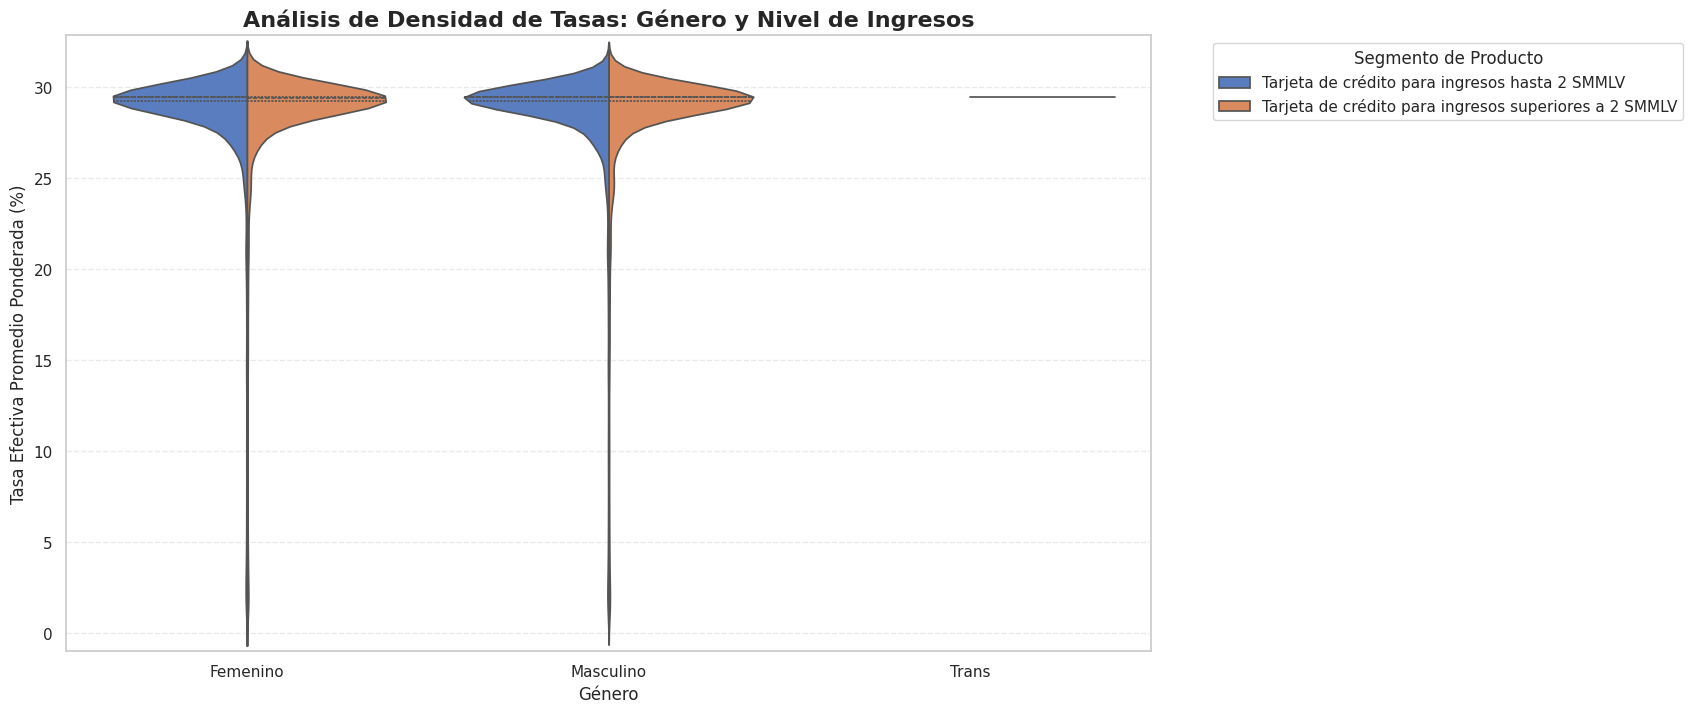

In [ ]:
df_clean = df[df['Tasa_efectiva_promedio_ponderada'] > 1]

plt.figure(figsize=(14, 8))

sns.violinplot(
    data=df_clean,
    x='Sexo',
    y='Tasa_efectiva_promedio_ponderada',
    hue='Producto de crédito',
    split=True,
    inner="quart",
    palette='muted',
    bw_method=0.2
)
plt.ylim(df_clean['Tasa_efectiva_promedio_ponderada'].min() - 2,
         df_clean['Tasa_efectiva_promedio_ponderada'].max() + 2)

plt.title('Análisis de Densidad de Tasas: Género y Nivel de Ingresos', fontsize=16, fontweight='bold')
plt.xlabel('Género', fontsize=12)
plt.ylabel('Tasa Efectiva Promedio Ponderada (%)', fontsize=12)
plt.legend(title='Segmento de Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

EL gráfico tipo violín, cruza el sexo del deudor con el tipo de producto y su nivel de ingreso.

La medianas:
Para el caso de los hombres y de mujeres soon iguales. Parece que el género no parece ser un factor de discriminación directa en el precio de la tasa de interés del préstamo.

Cabe aclarar que solo se presentan 5 registros de personas transexuales lo que representa un 0.0003% , por lo que la información parece nula.

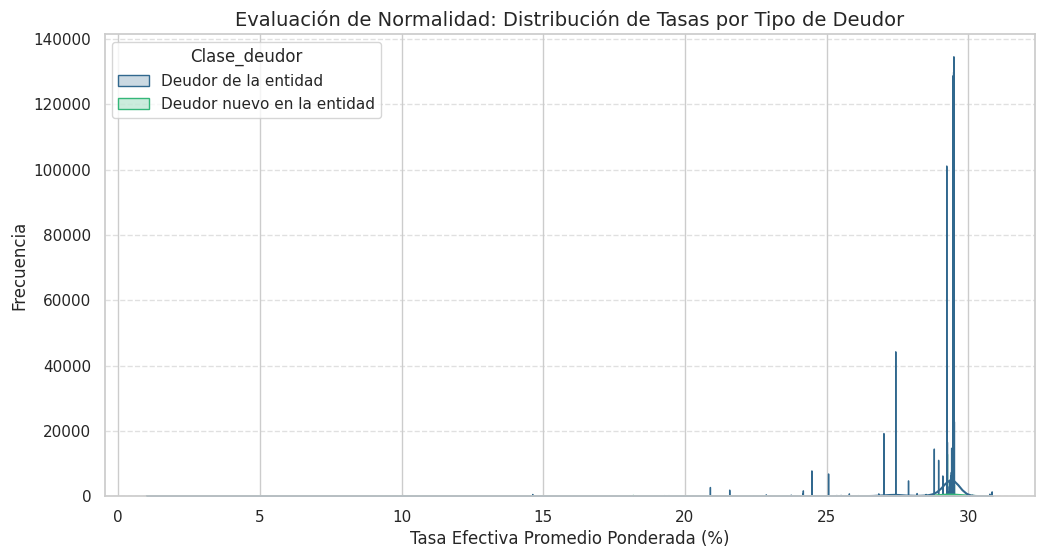

In [ ]:
# Filtramos las tasas mayores a 1 para evitar el sesgo del cero y ver la distribución real
df_filtered = df[df['Tasa_efectiva_promedio_ponderada'] > 1]

plt.figure(figsize=(12, 6))

# Graficamos la distribución para evaluar normalidad
sns.histplot(data=df_filtered, x='Tasa_efectiva_promedio_ponderada',
             hue='Clase_deudor', kde=True, element="step", palette='viridis')

plt.title('Evaluación de Normalidad: Distribución de Tasas por Tipo de Deudor', fontsize=14)
plt.xlabel('Tasa Efectiva Promedio Ponderada (%)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Se observa que los datos no cumplieron con el supuesto de normalidad

EL histograma mustra como se distribuyen las tasas de interés según el tipo de deudor, nuevo o antiguo

COmo los datos no siguen una distribución normal, se observan sesgos al extremo derecho donde la gran mayoría de las tasas se amontonan entre 27% y 31%

El pico cercano al 30% de la tasa efectiva promedio ponderada, representa a tasa de "usura" en Colombia. Lo que indica que no hay una distribución natural basada en el riesgo, sino una forzada a lo que se permite legalmente en el país

/tmp/ipython-input-839/530903500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='Rango_monto_desembolsado', y='Tasa_efectiva_promedio_ponderada',


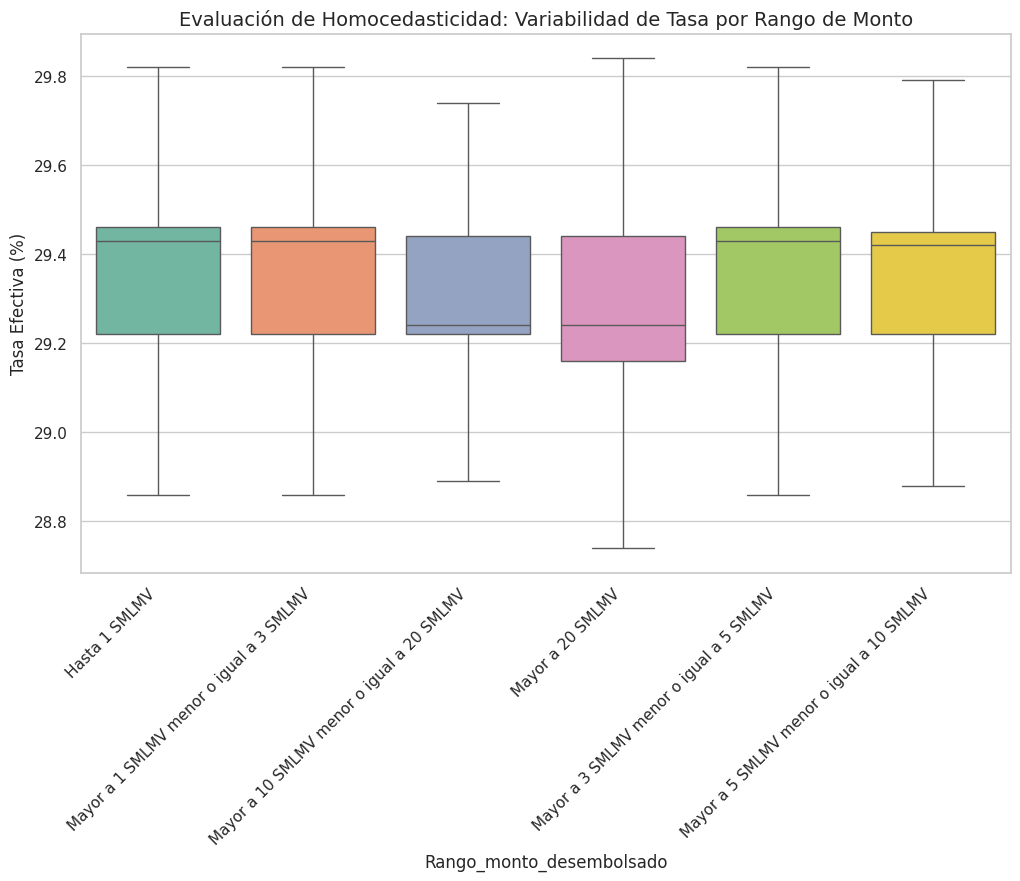

In [ ]:
plt.figure(figsize=(12, 7))

# Usamos un boxplot con "puntos" (stripplot) encima para ver la varianza
sns.boxplot(data=df_filtered, x='Rango_monto_desembolsado', y='Tasa_efectiva_promedio_ponderada',
            palette='Set2', showfliers=False) # showfliers=False limpia el ruido visual

plt.title('Evaluación de Homocedasticidad: Variabilidad de Tasa por Rango de Monto', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Tasa Efectiva (%)')
plt.show()

Este diagrama de cajas permite comparar la dispersión de la tasa de interés en diferentes rangos de monto desembolsado. Se oberva que cumle con el supuesto de homocedasticidad puesto que todas las cajas tienen un valor muy similar y las medianas están cercanas entre sí. Esto significa que la variabilidad del costo del crédito es constante.

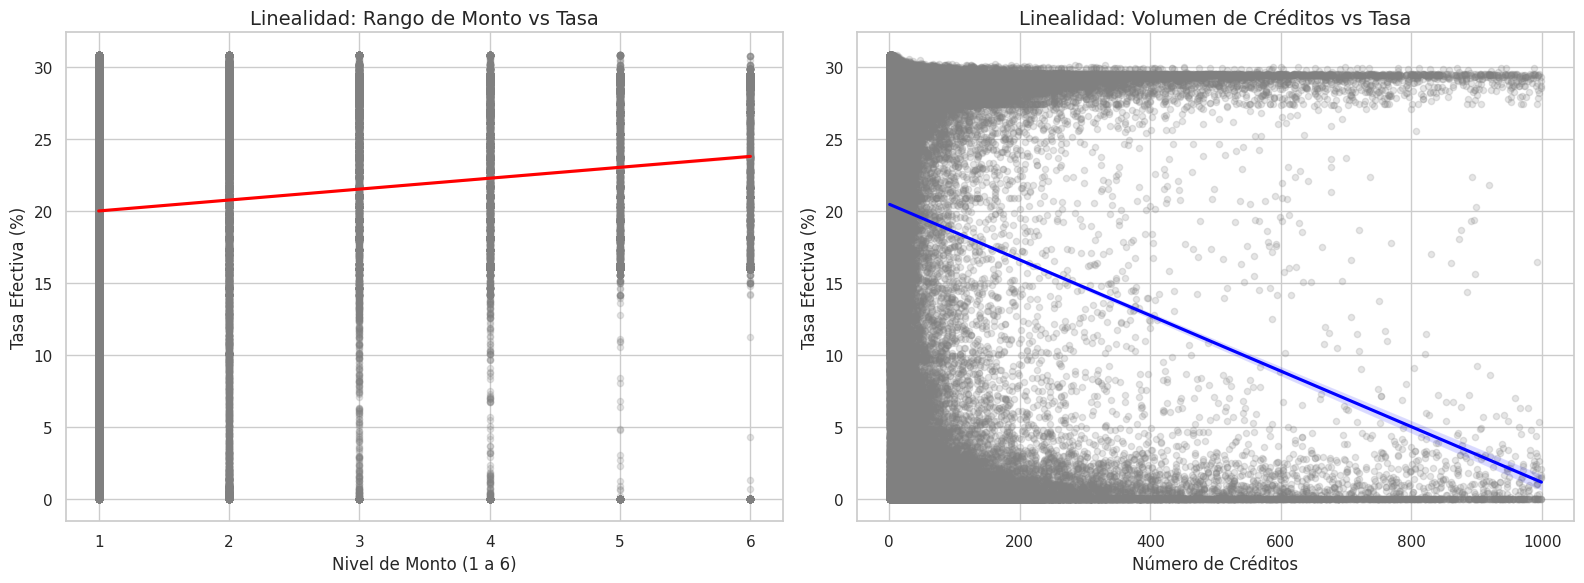

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aseguramos que la columna sea numérica y no contenga categorías conflictivas
# Mapeamos los rangos a enteros simples
monto_map = {
    'Hasta 1 SMLMV': 1,
    'Mayor a 1 SMLMV menor o igual a 3 SMLMV': 2,
    'Mayor a 3 SMLMV menor o igual a 5 SMLMV': 3,
    'Mayor a 5 SMLMV menor o igual a 10 SMLMV': 4,
    'Mayor a 10 SMLMV menor o igual a 20 SMLMV': 5,
    'Mayor a 20 SMLMV': 6
}

# Usamos .copy() para evitar advertencias de SettingWithCopy
df_linear = df.copy()
df_linear['Monto_Num'] = df_linear['Rango_monto_desembolsado'].map(monto_map)

# Convertimos explícitamente a float para que regplot no tenga problemas de tipos
df_linear['Monto_Num'] = pd.to_numeric(df_linear['Monto_Num'], errors='coerce')
df_linear['Tasa_Num'] = pd.to_numeric(df_linear['Tasa_efectiva_promedio_ponderada'], errors='coerce')

# Eliminamos filas con NaN resultantes de la conversión si las hay
df_linear = df_linear.dropna(subset=['Monto_Num', 'Tasa_Num'])

# 2. Gráfico de dispersión con líneas de tendencia
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subgráfico 1: Monto vs Tasa
sns.regplot(x='Monto_Num', y='Tasa_Num', data=df_linear, ax=axes[0],
            scatter_kws={'s': 20, 'alpha': 0.2, 'color': 'gray'},
            line_kws={'color': 'red'})
axes[0].set_title('Linealidad: Rango de Monto vs Tasa', fontsize=14)
axes[0].set_xlabel('Nivel de Monto (1 a 6)', fontsize=12)
axes[0].set_ylabel('Tasa Efectiva (%)', fontsize=12)

# Subgráfico 2: Cantidad de Créditos vs Tasa
sns.regplot(x='Numero_de_creditos_desembolsados', y='Tasa_Num', data=df_linear, ax=axes[1],
            scatter_kws={'s': 20, 'alpha': 0.2, 'color': 'gray'},
            line_kws={'color': 'blue'})
axes[1].set_title('Linealidad: Volumen de Créditos vs Tasa', fontsize=14)
axes[1].set_xlabel('Número de Créditos', fontsize=12)
axes[1].set_ylabel('Tasa Efectiva (%)', fontsize=12)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


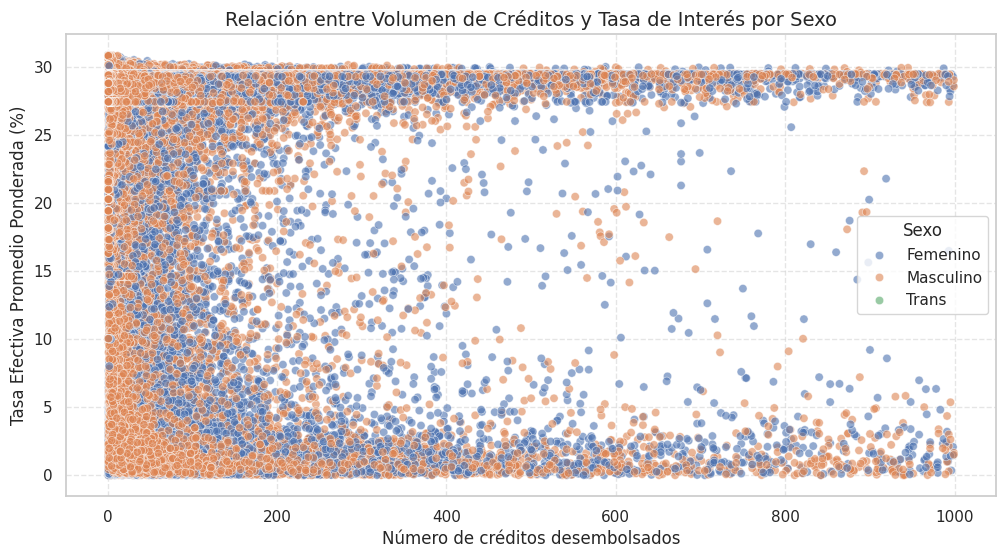

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtramos tasas en 0 para que el gráfico tenga sentido y escala real
df_plot = df[df['Tasa_efectiva_promedio_ponderada'] > 0]

plt.figure(figsize=(12, 6))

# 2. Adaptación del Scatterplot:
# x = Numero_de_creditos_desembolsados (equivalente a 'absences' como variable independiente)
# y = Tasa_efectiva_promedio_ponderada (equivalente a 'G3' como resultado)
sns.scatterplot(
    x='Numero_de_creditos_desembolsados',
    y='Tasa_efectiva_promedio_ponderada',
    hue='Sexo',
    data=df_plot,
    alpha=0.6
)

plt.title("Relación entre Volumen de Créditos y Tasa de Interés por Sexo", fontsize=14)
plt.xlabel("Número de créditos desembolsados", fontsize=12)
plt.ylabel("Tasa Efectiva Promedio Ponderada (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Hay una linealidad muy débil, casi que inexistente, por lo que a se puede deducir que las tasas de interés de los bancos no se reducen o aumentan según el monto prestado.

## <span style="color:Blue;"><strong>5. Interpretaciones iniciales</strong></span>

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>¿Qué tendencias o patrones básicos se observan?</b>  
<ul>
  <li>La Tasa efectiva promedio ponderada no está relacionada directamente con la variable de sexo</li>
  <li>A pesar del monto del crédito, la tasa de interés se mantiene igual</li>
  <li>La mayoría de las persona con crédito, no proporciona información acerca de su grupo étnico</li>
  <li>Existe una concentración masiva de registros en el límite superior de las tasas (cerca del 29%-30%), lo que indica que el mercado de tarjetas de crédito en Colombia opera muy cerca de la tasa de usura legalmente permitida.</li>
</ul>
</div>

<br>

<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b>¿Qué limitaciones tiene la base de datos?</b>  
<ul>
  <li>No hay balance de género uniforme (la distribución de sex puede estar sesgada).</li>
  <li>No hay presencia de normalidad den los datos por lo que se observan muchos valores atípicos en ausencias (absences).</li>
  <li>La variable sexo incluye valores extremos que pueden distorsionar los análisis.</li>
  <li>El tamaño del archivo (aprox. 500 MB) representa una limitación técnica para el almacenamiento y procesamiento en repositorios estándar como GitHub sin el uso de LFS o conexiones vía API.</li>
</ul>
</div>

<br>

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b>¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?</b>  
<ul>
  <li>Aunque el género no es determinante, el tipo de producto (ingresos < 2 SMMLV vs > 2 SMMLV) actúa como el principal filtro de acceso a tasas preferenciales.</li>
  <li>La tasa de usura actúa como un "atractor" que uniformiza el mercado, reduciendo la capacidad de las entidades para diferenciar precios basados en el perfil de riesgo individual del solicitante.</li>
</ul>
</div>


## <span style="color:Blue;"><strong>6. Conclusiones</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Resumen de los principales hallazgos iniciales.</b><br>
<b>- Reflexión sobre cómo este entregable contribuye al desarrollo del proyecto completo.</b><br>
</div>
<ul>
<li>Al evaluar los supuestos de normalidad, linealidad y homocedasticidad, ahora sabemos que para futuros modelos predictivos o pruebas de hipótesis no podemos confiar en estadística paramétrica tradicional. El proyecto deberá virar hacia métodos robustos o no paramétricos.</li>
<li>Inicialmente nos enfocamos en el Sexo y Grupo Étnico; sin embargo, el EDA nos reveló que la variable "Rango de Monto" tiene un peso explicativo mucho mayor en la variación de la tasa.</li>
<li>etectamos que la variable de Grupo Étnico tiene un vacío de información crítico. Esto nos permite ajustar las expectativas del proyecto final</li>
----------------------------------------------
<li>Las distribuciones de tasas para hombresy mujeres son notablemente similares. Esto sugiere que, a nivel macro, el sistema financiero colombiano aplica una estandarización de costos donde el sexo no es la variable de segmentación principal.</li>
<li>La falta de normalidad y el sesgo extremo en las gráficas demuestran que el mercado no se comporta de forma "natural", sino que está condicionado por el techo legal de la tasa de usura</li>
<li>A pesar de la variabilidad en los montos, la dispersión de las tasas se mantiene constante (homocedasticidad)</li>
</ul>